# Stage 07 — German Credit DiCE Counterfactuals

This notebook generates constrained counterfactuals for the frozen weighted model and fixed 20-case cohort. Only credit duration, credit amount and installment rate may vary.


## 1. Stage 06 faithfulness provenance gate

Matching SHAP and LIME sensitivity values are valid only if both methods independently selected the same feature and intervention.


In [1]:
import json
import time
import traceback
from datetime import datetime, timezone
from pathlib import Path

import dice_ml
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score, roc_auc_score,
)

RANDOM_STATE = 42
DECISION_THRESHOLD = 0.50
FIRST_PASS_TIMEOUT_SECONDS = 30
RETRY_TIMEOUT_SECONDS = 90
TOTAL_CFS = 1
DICE_METHOD = "genetic"
RAW_TARGET = "class"
TARGET = "TARGET"

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "german_credit":
    candidate = NOTEBOOK_DIR / "backend" / "ml" / "german_credit"
    if candidate.exists():
        NOTEBOOK_DIR = candidate
    else:
        raise RuntimeError("Run from backend/ml/german_credit or the project root.")
BACKEND_DIR = NOTEBOOK_DIR.parents[1]
RAW_PATH = BACKEND_DIR / "data" / "german_credit" / "raw" / "german_credit_raw.csv"
ARTIFACTS_DIR = BACKEND_DIR / "artifacts" / "german_credit"
PLOTS_DIR = ARTIFACTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SHAP_TOP_PATH = ARTIFACTS_DIR / "shap_top_factors.csv"
SHAP_FAITH_PATH = ARTIFACTS_DIR / "shap_preliminary_faithfulness.csv"
LIME_TOP_PATH = ARTIFACTS_DIR / "lime_top_factors.csv"
LIME_FAITH_PATH = ARTIFACTS_DIR / "lime_preliminary_faithfulness.csv"
shap_top = pd.read_csv(SHAP_TOP_PATH)
shap_faith = pd.read_csv(SHAP_FAITH_PATH)
lime_top = pd.read_csv(LIME_TOP_PATH)
lime_faith = pd.read_csv(LIME_FAITH_PATH)

provenance_rows = []
for case_id in [f"GER_XAI_{number:03d}" for number in range(1, 6)]:
    shap_first = shap_top.loc[shap_top["case_id"].eq(case_id)].sort_values("rank").iloc[0]
    lime_first = lime_top.loc[lime_top["case_id"].eq(case_id)].sort_values("rank").iloc[0]
    shap_result = shap_faith.loc[shap_faith["case_id"].eq(case_id)].iloc[0]
    lime_result = lime_faith.loc[lime_faith["case_id"].eq(case_id)].iloc[0]
    same_intervention = (
        shap_result["intervened_feature"] == lime_result["intervened_feature"]
        and str(shap_result["replacement_value"]) == str(lime_result["replacement_value"])
    )
    provenance_rows.append({
        "case_id": case_id,
        "top_shap_feature": shap_first["original_feature"],
        "top_lime_feature": lime_first["original_feature"],
        "same_top_feature": shap_first["original_feature"] == lime_first["original_feature"],
        "shap_replacement_value": shap_result["replacement_value"],
        "lime_replacement_value": lime_result["replacement_value"],
        "same_intervention": same_intervention,
        "shap_absolute_score_change": shap_result["absolute_score_change"],
        "lime_absolute_score_change": lime_result["absolute_score_change"],
    })
faithfulness_provenance = pd.DataFrame(provenance_rows)
faithfulness_provenance["same_score_change"] = np.isclose(
    faithfulness_provenance["shap_absolute_score_change"],
    faithfulness_provenance["lime_absolute_score_change"], atol=1e-15,
)
assert faithfulness_provenance["same_top_feature"].all()
assert faithfulness_provenance["same_intervention"].all()
assert faithfulness_provenance["same_score_change"].all()
FAITHFULNESS_PROVENANCE_PATH = ARTIFACTS_DIR / "stage06_faithfulness_provenance_check.csv"
faithfulness_provenance.to_csv(FAITHFULNESS_PROVENANCE_PATH, index=False)
display(faithfulness_provenance)
print("Stage 06 faithfulness provenance check: legitimate independent agreement.")


,case_id,top_shap_feature,top_lime_feature,same_top_feature,shap_replacement_value,lime_replacement_value,same_intervention,shap_absolute_score_change,lime_absolute_score_change,same_score_change
0,GER_XAI_001,Attribute1,Attribute1,True,No checking account,No checking account,True,0.133753,0.133753,True
1,GER_XAI_002,Attribute1,Attribute1,True,No checking account,No checking account,True,0.276381,0.276381,True
2,GER_XAI_003,Attribute1,Attribute1,True,No checking account,No checking account,True,0.628390,0.628390,True
3,GER_XAI_004,Attribute1,Attribute1,True,No checking account,No checking account,True,0.482999,0.482999,True
4,GER_XAI_005,Attribute2,Attribute2,True,18,18,True,0.053795,0.053795,True


Stage 06 faithfulness provenance check: legitimate independent agreement.


## 2. Frozen reconstruction


In [2]:
paths = {
    "selection": ARTIFACTS_DIR / "selected_features.json",
    "display_mapping": ARTIFACTS_DIR / "feature_display_mapping.json",
    "category_mapping": ARTIFACTS_DIR / "category_value_mapping.json",
    "train_indices": ARTIFACTS_DIR / "train_indices.csv",
    "test_indices": ARTIFACTS_DIR / "test_indices.csv",
    "preprocessor": ARTIFACTS_DIR / "preprocessor.joblib",
    "preprocessing_metadata": ARTIFACTS_DIR / "preprocessing_metadata.json",
    "transformed_mapping": ARTIFACTS_DIR / "transformed_feature_mapping.csv",
    "actionability": ARTIFACTS_DIR / "dice_actionability_candidates.csv",
    "model": ARTIFACTS_DIR / "xgboost_credit_model.joblib",
    "model_metadata": ARTIFACTS_DIR / "model_metadata.json",
    "xai_cases": ARTIFACTS_DIR / "xai_evaluation_cases.csv",
}
assert all(path.exists() for path in paths.values())
raw_df = pd.read_csv(RAW_PATH)
selection = json.loads(paths["selection"].read_text(encoding="utf-8"))
display_mapping = json.loads(paths["display_mapping"].read_text(encoding="utf-8"))
category_mapping = json.loads(paths["category_mapping"].read_text(encoding="utf-8"))
preprocessing_metadata = json.loads(paths["preprocessing_metadata"].read_text(encoding="utf-8"))
model_metadata = json.loads(paths["model_metadata"].read_text(encoding="utf-8"))
train_indices = pd.read_csv(paths["train_indices"])["row_index"].astype(int)
test_indices = pd.read_csv(paths["test_indices"])["row_index"].astype(int)
actionability = pd.read_csv(paths["actionability"])
xai_cases = pd.read_csv(paths["xai_cases"])
preprocessor = joblib.load(paths["preprocessor"])
model = joblib.load(paths["model"])

selected_features = selection["selected_features"]
numeric_features = selection["numeric_selected_features"]
categorical_features = selection["categorical_selected_features"]
y_all = raw_df[RAW_TARGET].map({1: 0, 2: 1}).rename(TARGET)
X_train_raw = raw_df.loc[train_indices, selected_features].copy()
X_test_raw = raw_df.loc[test_indices, selected_features].copy()
y_train = y_all.loc[train_indices].copy()
y_test = y_all.loc[test_indices].copy()
X_train_processed = preprocessor.transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)
test_probabilities = model.predict_proba(X_test_processed)[:, 1]
test_predictions = (test_probabilities >= DECISION_THRESHOLD).astype(int)

reproduced_metrics = {
    "roc_auc": roc_auc_score(y_test, test_probabilities),
    "pr_auc": average_precision_score(y_test, test_probabilities),
    "accuracy": accuracy_score(y_test, test_predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_predictions),
    "precision_positive": precision_score(y_test, test_predictions, zero_division=0),
    "recall_positive": recall_score(y_test, test_predictions, zero_division=0),
    "f1_positive": f1_score(y_test, test_predictions, zero_division=0),
}
metric_differences = {key: abs(value - model_metadata["test_metrics"][key]) for key, value in reproduced_metrics.items()}
assert X_train_processed.shape == (800, 54) and X_test_processed.shape == (200, 54)
assert np.isfinite(X_train_processed).all() and np.isfinite(X_test_processed).all()
assert max(metric_differences.values()) <= 1e-12
print(f"Training rows: {len(X_train_raw)}")
print(f"Test rows: {len(X_test_raw)}")
print("Frozen predictions reproduced: True")


Training rows: 800
Test rows: 200
Frozen predictions reproduced: True


In [3]:
assert len(xai_cases) == 20 and xai_cases["row_index"].is_unique
assert xai_cases["case_type"].value_counts().to_dict() == {
    "high-confidence positive": 5, "borderline positive": 5,
    "high-confidence negative": 5, "borderline negative": 5,
}
test_position = {row_index: position for position, row_index in enumerate(X_test_raw.index)}
case_positions = np.array([test_position[int(row_index)] for row_index in xai_cases["row_index"]])
assert np.allclose(xai_cases["predicted_probability"], test_probabilities[case_positions], atol=1e-12)
assert np.array_equal(xai_cases["predicted_class"], test_predictions[case_positions])
assert np.array_equal(xai_cases["true_target"], y_test.iloc[case_positions].to_numpy())
print("Fixed XAI cases verified: 20")


Fixed XAI cases verified: 20


## 3. Actionability and permitted domains

Duration and installment rate use observed training values. Credit amount may vary continuously within the training range.


In [4]:
FEATURES_TO_VARY = ["Attribute2", "Attribute5", "Attribute8"]
assert actionability.loc[
    actionability["actionability_status"].eq("directly_actionable_candidate"), "feature"
].tolist() == FEATURES_TO_VARY

duration_min = int(X_train_raw["Attribute2"].min())
duration_max = int(X_train_raw["Attribute2"].max())
allowed_duration = list(range(duration_min, duration_max + 1))
allowed_installment_rates = sorted(int(value) for value in X_train_raw["Attribute8"].unique())
credit_amount_range = [float(X_train_raw["Attribute5"].min()), float(X_train_raw["Attribute5"].max())]
permitted_range = {
    "Attribute2": allowed_duration,
    "Attribute5": credit_amount_range,
    "Attribute8": allowed_installment_rates,
}
dice_generation_permitted_range = {
    "Attribute2": [duration_min, duration_max],
    "Attribute5": credit_amount_range,
    "Attribute8": [str(value) for value in allowed_installment_rates],
}
range_rows = [
    {
        "feature": "Attribute2", "display_feature": display_mapping["Attribute2"],
        "training_min": min(allowed_duration), "training_max": max(allowed_duration),
        "integer_or_continuous": "integer months within training range",
        "allowed_values": json.dumps(allowed_duration),
    },
    {
        "feature": "Attribute5", "display_feature": display_mapping["Attribute5"],
        "training_min": credit_amount_range[0], "training_max": credit_amount_range[1],
        "integer_or_continuous": "continuous numeric within training range",
        "allowed_values": "",
    },
    {
        "feature": "Attribute8", "display_feature": display_mapping["Attribute8"],
        "training_min": min(allowed_installment_rates), "training_max": max(allowed_installment_rates),
        "integer_or_continuous": "ordinal integer; observed values only",
        "allowed_values": json.dumps(allowed_installment_rates),
    },
]
dice_permitted_ranges = pd.DataFrame(range_rows)
PERMITTED_RANGES_PATH = ARTIFACTS_DIR / "dice_permitted_ranges.csv"
dice_permitted_ranges.to_csv(PERMITTED_RANGES_PATH, index=False)
display(dice_permitted_ranges)


,feature,display_feature,training_min,training_max,integer_or_continuous,allowed_values
0,Attribute2,Credit duration (months),4.0,60.0,integer months within training range,"[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,..."
1,Attribute5,Credit amount (DM),276.0,15945.0,continuous numeric within training range,
2,Attribute8,Installment rate (% disposable income),1.0,4.0,ordinal integer; observed values only,"[1, 2, 3, 4]"


## 4. Frozen prediction interface


In [5]:
class FrozenCreditModel:
    def __init__(self, frozen_preprocessor, frozen_model, feature_names, numeric_names, category_names):
        self.preprocessor = frozen_preprocessor
        self.model = frozen_model
        self.feature_names = list(feature_names)
        self.numeric_names = list(numeric_names)
        self.category_names = list(category_names)
        self.classes_ = np.array([0, 1])

    def _frame(self, rows):
        if isinstance(rows, pd.DataFrame):
            frame = rows.copy()
        else:
            frame = pd.DataFrame(rows, columns=self.feature_names)
        frame = frame[self.feature_names].copy()
        for feature in self.numeric_names:
            frame[feature] = pd.to_numeric(frame[feature])
        frame["Attribute2"] = np.rint(frame["Attribute2"]).astype(int)
        frame["Attribute8"] = np.rint(frame["Attribute8"]).astype(int)
        for feature in self.category_names:
            frame[feature] = frame[feature].astype(str)
        return frame

    def predict_proba(self, rows):
        frame = self._frame(rows)
        processed = self.preprocessor.transform(frame)
        return self.model.predict_proba(processed)

    def predict(self, rows):
        return (self.predict_proba(rows)[:, 1] >= DECISION_THRESHOLD).astype(int)

frozen_wrapper = FrozenCreditModel(
    preprocessor, model, selected_features, numeric_features, categorical_features
)
wrapper_probabilities = frozen_wrapper.predict_proba(X_test_raw)[:, 1]
wrapper_max_difference = float(np.max(np.abs(wrapper_probabilities - test_probabilities)))
assert wrapper_max_difference <= 1e-12
print(f"Maximum wrapper probability difference: {wrapper_max_difference:.12g}")


Maximum wrapper probability difference: 0


## 5. Training-only DiCE interface


In [6]:
dice_reference = X_train_raw.copy()
dice_reference[TARGET] = y_train.to_numpy()
# Discrete actionable domains are categorical in DiCE; fixed numeric fields retain their numeric type.
dice_continuous_features = [feature for feature in numeric_features if feature != "Attribute8"]
dice_data = dice_ml.Data(
    dataframe=dice_reference,
    continuous_features=dice_continuous_features,
    outcome_name=TARGET,
)
dice_model = dice_ml.Model(model=frozen_wrapper, backend="sklearn", model_type="classifier")
dice_explainer = dice_ml.Dice(dice_data, dice_model, method=DICE_METHOD)
print(f"DiCE reference rows: {len(dice_reference)}")
print(f"Method: {DICE_METHOD}")


DiCE reference rows: 800
Method: genetic


## 6. Generation and persistence helpers


In [7]:
FIRST_PASS_PATH = ARTIFACTS_DIR / "dice_generation_first_pass.csv"
FIRST_PASS_CF_PATH = ARTIFACTS_DIR / "dice_first_pass_counterfactuals.csv"
RETRY_PATH = ARTIFACTS_DIR / "dice_timeout_retry.csv"
RETRY_CF_PATH = ARTIFACTS_DIR / "dice_timeout_retry_counterfactuals.csv"
VALID_CF_PATH = ARTIFACTS_DIR / "dice_counterfactuals.csv"
FEATURE_CHANGES_PATH = ARTIFACTS_DIR / "dice_feature_changes.csv"
FINAL_STATUS_PATH = ARTIFACTS_DIR / "dice_final_case_status.csv"

first_pass_columns = [
    "case_id", "original_probability", "original_class", "desired_class",
    "start_time", "elapsed_seconds", "counterfactuals_requested",
    "counterfactuals_found", "generation_status", "exception_class", "error_message",
]
retry_columns = [
    "case_id", "first_pass_status", "first_pass_elapsed_seconds",
    "retry_timeout_seconds", "retry_elapsed_seconds", "original_probability",
    "original_class", "desired_class", "counterfactuals_requested",
    "counterfactuals_found", "retry_status", "exception_class", "error_message",
]
cf_prefix_columns = [
    "case_id", "counterfactual_id", "row_index", "source",
    "original_probability", "original_class", "desired_class",
    "counterfactual_probability", "counterfactual_class",
    "valid_counterfactual", "permitted_ranges_respected",
    "only_actionable_changed", "integer_constraints_respected",
    "unchanged_features_unchanged",
]

def atomic_csv(frame, path):
    temporary = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temporary, index=False)
    temporary.replace(path)

def classify_generation(exception_class, message, returned_rows):
    if returned_rows > 0:
        return "success"
    text = (message or "").lower()
    if exception_class == "ProcessTimeoutError":
        return "timeout"
    if any(fragment in text for fragment in [
        "no counterfactual", "no counterfactuals", "counterfactuals not found",
        "unable to find", "no valid counterfactual",
    ]):
        return "no_counterfactual_returned"
    return "technical_error"

def isolated_dice_generation(explainer, query, desired_class):
    np.random.seed(RANDOM_STATE)
    result = explainer.generate_counterfactuals(
        query_instances=query,
        total_CFs=TOTAL_CFS,
        desired_class=int(desired_class),
        features_to_vary=FEATURES_TO_VARY,
        permitted_range=dice_generation_permitted_range,
        stopping_threshold=DECISION_THRESHOLD,
        verbose=False,
    )
    final_frame = result.cf_examples_list[0].final_cfs_df
    if final_frame is None or final_frame.empty:
        return []
    return final_frame.to_dict(orient="records")

def bounded_generation(explainer, query, desired_class, timeout_seconds):
    try:
        result = Parallel(n_jobs=2, backend="loky", timeout=timeout_seconds)([
            delayed(isolated_dice_generation)(explainer, query, desired_class)
        ])[0]
        return result, "", "", ""
    except Exception as error:
        name = type(error).__name__
        message = str(error)
        if name in {"TimeoutError", "TerminatedWorkerError"} and "timeout" in (message.lower() + name.lower()):
            return [], "ProcessTimeoutError", f"Counterfactual search exceeded {timeout_seconds} seconds.", traceback.format_exc()
        return [], name, message, traceback.format_exc()

def normalize_counterfactual(record, query):
    row = query.iloc[0].copy()
    for feature in selected_features:
        if feature in record:
            row[feature] = record[feature]
    row["Attribute2"] = int(round(float(row["Attribute2"])))
    row["Attribute5"] = float(row["Attribute5"])
    row["Attribute8"] = int(round(float(row["Attribute8"])))
    for feature in numeric_features:
        row[feature] = float(row[feature]) if feature == "Attribute5" else int(round(float(row[feature])))
    for feature in categorical_features:
        row[feature] = str(row[feature])
    return row

def validate_counterfactual(case, query, normalized_row, source):
    counterfactual_frame = pd.DataFrame([normalized_row[selected_features]], columns=selected_features)
    probability = float(frozen_wrapper.predict_proba(counterfactual_frame)[0, 1])
    predicted_class = int(probability >= DECISION_THRESHOLD)
    changed_features = [
        feature for feature in selected_features
        if not (
            np.isclose(float(query.iloc[0][feature]), float(normalized_row[feature]))
            if feature in numeric_features else query.iloc[0][feature] == normalized_row[feature]
        )
    ]
    ranges_ok = (
        int(normalized_row["Attribute2"]) in allowed_duration
        and credit_amount_range[0] <= float(normalized_row["Attribute5"]) <= credit_amount_range[1]
        and int(normalized_row["Attribute8"]) in allowed_installment_rates
    )
    integer_ok = (
        float(normalized_row["Attribute2"]).is_integer()
        and float(normalized_row["Attribute8"]).is_integer()
    )
    only_actionable = set(changed_features).issubset(FEATURES_TO_VARY)
    unchanged_ok = all(
        query.iloc[0][feature] == normalized_row[feature]
        for feature in selected_features if feature not in FEATURES_TO_VARY
    )
    valid = predicted_class == int(case.desired_class) and ranges_ok and integer_ok and only_actionable and unchanged_ok
    record = {
        "case_id": case.case_id,
        "counterfactual_id": f"{case.case_id}_CF_001",
        "row_index": int(case.row_index),
        "source": source,
        "original_probability": float(case.original_probability),
        "original_class": int(case.original_class),
        "desired_class": int(case.desired_class),
        "counterfactual_probability": probability,
        "counterfactual_class": predicted_class,
        "valid_counterfactual": valid,
        "permitted_ranges_respected": ranges_ok,
        "only_actionable_changed": only_actionable,
        "integer_constraints_respected": integer_ok,
        "unchanged_features_unchanged": unchanged_ok,
    }
    record.update({feature: normalized_row[feature] for feature in selected_features})
    return record


## 7. First-pass generation

The switch is enabled only for the initial persisted run. Completed cases are skipped when resuming an interrupted run.


In [8]:
RUN_FULL_FIRST_PASS = False
case_generation_table = xai_cases.rename(columns={
    "predicted_probability": "original_probability",
    "predicted_class": "original_class",
}).copy()
case_generation_table["desired_class"] = 1 - case_generation_table["original_class"]

if FIRST_PASS_PATH.exists():
    first_pass = pd.read_csv(FIRST_PASS_PATH, keep_default_na=False)
else:
    first_pass = pd.DataFrame(columns=first_pass_columns)
if FIRST_PASS_CF_PATH.exists():
    first_pass_cfs = pd.read_csv(FIRST_PASS_CF_PATH, keep_default_na=False)
else:
    first_pass_cfs = pd.DataFrame(columns=cf_prefix_columns + selected_features)

invalid_setup_mask = (
    first_pass["exception_class"].eq("UserConfigValidationException")
    & first_pass["error_message"].str.contains("does not occur in the training data for feature Attribute2", na=False)
)
if len(first_pass) == 20 and invalid_setup_mask.all():
    invalid_setup_path = ARTIFACTS_DIR / "dice_generation_invalid_setup.csv"
    atomic_csv(first_pass, invalid_setup_path)
    first_pass = pd.DataFrame(columns=first_pass_columns)
    first_pass_cfs = pd.DataFrame(columns=cf_prefix_columns + selected_features)
    atomic_csv(first_pass_cfs, FIRST_PASS_CF_PATH)
    print("Archived invalid pre-search configuration run; starting corrected first pass.")

duration_setup_mask = (
    first_pass["exception_class"].eq("ValueError")
    & first_pass["error_message"].str.contains("Attribute2.*outside the dataset", regex=True, na=False)
)
if len(first_pass) == 20 and duration_setup_mask.any():
    atomic_csv(first_pass, ARTIFACTS_DIR / "dice_generation_discrete_duration_run.csv")
    atomic_csv(first_pass_cfs, ARTIFACTS_DIR / "dice_discrete_duration_counterfactuals.csv")
    if RETRY_PATH.exists():
        atomic_csv(pd.read_csv(RETRY_PATH, keep_default_na=False), ARTIFACTS_DIR / "dice_discrete_duration_retry.csv")
    first_pass = pd.DataFrame(columns=first_pass_columns)
    first_pass_cfs = pd.DataFrame(columns=cf_prefix_columns + selected_features)
    atomic_csv(first_pass_cfs, FIRST_PASS_CF_PATH)
    atomic_csv(pd.DataFrame(columns=retry_columns), RETRY_PATH)
    atomic_csv(pd.DataFrame(columns=cf_prefix_columns + selected_features), RETRY_CF_PATH)
    print("Archived discrete-duration setup run; starting final consistent first pass.")

if RUN_FULL_FIRST_PASS:
    completed_ids = set(first_pass["case_id"])
    for case in case_generation_table.itertuples(index=False):
        if case.case_id in completed_ids:
            continue
        print(f"Generating {case.case_id}...")
        query = X_test_raw.loc[[int(case.row_index)], selected_features].copy()
        started_at = datetime.now(timezone.utc).isoformat()
        started = time.perf_counter()
        returned, exception_class, error_message, _ = bounded_generation(
            dice_explainer, query, case.desired_class, FIRST_PASS_TIMEOUT_SECONDS
        )
        elapsed = time.perf_counter() - started
        status = classify_generation(exception_class, error_message, len(returned))
        new_cf_records = []
        if returned:
            normalized = normalize_counterfactual(returned[0], query)
            new_cf_records.append(validate_counterfactual(case, query, normalized, "first_pass"))
            first_pass_cfs = pd.concat([first_pass_cfs, pd.DataFrame(new_cf_records)], ignore_index=True)
            atomic_csv(first_pass_cfs, FIRST_PASS_CF_PATH)
        first_pass_row = pd.DataFrame([{
            "case_id": case.case_id,
            "original_probability": case.original_probability,
            "original_class": case.original_class,
            "desired_class": case.desired_class,
            "start_time": started_at,
            "elapsed_seconds": elapsed,
            "counterfactuals_requested": TOTAL_CFS,
            "counterfactuals_found": len(returned),
            "generation_status": status,
            "exception_class": exception_class,
            "error_message": error_message,
        }])
        first_pass = pd.concat([first_pass, first_pass_row], ignore_index=True)
        atomic_csv(first_pass[first_pass_columns], FIRST_PASS_PATH)
        print(f"Finished {case.case_id} in {elapsed:.2f}s: {status}")
else:
    if not FIRST_PASS_PATH.exists() or not FIRST_PASS_CF_PATH.exists():
        raise FileNotFoundError("Saved first-pass artifacts are required when RUN_FULL_FIRST_PASS is False.")
    first_pass = pd.read_csv(FIRST_PASS_PATH, keep_default_na=False)
    first_pass_cfs = pd.read_csv(FIRST_PASS_CF_PATH, keep_default_na=False)

assert len(first_pass) == 20
assert first_pass["case_id"].is_unique
print(first_pass["generation_status"].value_counts())


generation_status
success                       12
no_counterfactual_returned     8
Name: count, dtype: int64


## 8. Timeout-only retry


In [9]:
RUN_TIMEOUT_RETRY = False
actual_timeout_ids = first_pass.loc[first_pass["generation_status"].eq("timeout"), "case_id"].tolist()
if RETRY_PATH.exists():
    retry_results = pd.read_csv(RETRY_PATH, keep_default_na=False)
else:
    retry_results = pd.DataFrame(columns=retry_columns)
if RETRY_CF_PATH.exists():
    retry_cfs = pd.read_csv(RETRY_CF_PATH, keep_default_na=False)
else:
    retry_cfs = pd.DataFrame(columns=cf_prefix_columns + selected_features)

if RUN_TIMEOUT_RETRY:
    completed_retry_ids = set(retry_results["case_id"])
    for case_id in actual_timeout_ids:
        if case_id in completed_retry_ids:
            continue
        case = case_generation_table.loc[case_generation_table["case_id"].eq(case_id)].iloc[0]
        first_row = first_pass.loc[first_pass["case_id"].eq(case_id)].iloc[0]
        query = X_test_raw.loc[[int(case["row_index"])], selected_features].copy()
        print(f"Retrying {case_id}...")
        started = time.perf_counter()
        returned, exception_class, error_message, _ = bounded_generation(
            dice_explainer, query, int(case["desired_class"]), RETRY_TIMEOUT_SECONDS
        )
        elapsed = time.perf_counter() - started
        retry_status = classify_generation(exception_class, error_message, len(returned))
        case_object = type("Case", (), {
            "case_id": case_id, "row_index": int(case["row_index"]),
            "original_probability": float(case["original_probability"]),
            "original_class": int(case["original_class"]),
            "desired_class": int(case["desired_class"]),
        })()
        if returned:
            normalized = normalize_counterfactual(returned[0], query)
            validated = validate_counterfactual(case_object, query, normalized, "timeout_retry")
            retry_cfs = pd.concat([retry_cfs, pd.DataFrame([validated])], ignore_index=True)
            atomic_csv(retry_cfs, RETRY_CF_PATH)
        retry_row = pd.DataFrame([{
            "case_id": case_id,
            "first_pass_status": first_row["generation_status"],
            "first_pass_elapsed_seconds": first_row["elapsed_seconds"],
            "retry_timeout_seconds": RETRY_TIMEOUT_SECONDS,
            "retry_elapsed_seconds": elapsed,
            "original_probability": case["original_probability"],
            "original_class": case["original_class"],
            "desired_class": case["desired_class"],
            "counterfactuals_requested": TOTAL_CFS,
            "counterfactuals_found": len(returned),
            "retry_status": retry_status,
            "exception_class": exception_class,
            "error_message": error_message,
        }])
        retry_results = pd.concat([retry_results, retry_row], ignore_index=True)
        atomic_csv(retry_results[retry_columns], RETRY_PATH)
        print(f"Finished retry {case_id} in {elapsed:.2f}s: {retry_status}")
else:
    if actual_timeout_ids and not RETRY_PATH.exists():
        raise FileNotFoundError("Saved retry metadata are required for first-pass timeout cases.")
    retry_results = pd.read_csv(RETRY_PATH, keep_default_na=False) if RETRY_PATH.exists() else pd.DataFrame(columns=retry_columns)
    retry_cfs = pd.read_csv(RETRY_CF_PATH, keep_default_na=False) if RETRY_CF_PATH.exists() else pd.DataFrame(columns=cf_prefix_columns + selected_features)

assert set(retry_results["case_id"]) == set(actual_timeout_ids)
print(retry_results["retry_status"].value_counts() if len(retry_results) else "No timeout retries required.")


No timeout retries required.


## 9. Final validated counterfactuals and statuses


In [10]:
all_returned_cfs = pd.concat([first_pass_cfs, retry_cfs], ignore_index=True)
if not all_returned_cfs.empty:
    all_returned_cfs = all_returned_cfs.drop_duplicates(["case_id", "source"], keep="last")
    valid_counterfactuals = all_returned_cfs.loc[
        all_returned_cfs["valid_counterfactual"].astype(str).str.lower().eq("true")
    ].copy()
else:
    valid_counterfactuals = pd.DataFrame(columns=cf_prefix_columns + selected_features)
atomic_csv(valid_counterfactuals, VALID_CF_PATH)

final_status_rows = []
for case in case_generation_table.itertuples(index=False):
    fp = first_pass.loc[first_pass["case_id"].eq(case.case_id)].iloc[0]
    retry = retry_results.loc[retry_results["case_id"].eq(case.case_id)]
    valid = valid_counterfactuals.loc[valid_counterfactuals["case_id"].eq(case.case_id)]
    retry_performed = not retry.empty
    retry_status = retry.iloc[0]["retry_status"] if retry_performed else ""
    retry_elapsed = float(retry.iloc[0]["retry_elapsed_seconds"]) if retry_performed else np.nan
    if not valid.empty:
        source = valid.iloc[0]["source"]
        final_status = "success_first_pass" if source == "first_pass" else "success_after_retry"
    elif fp["generation_status"] == "no_counterfactual_returned":
        source, final_status = "none", "no_counterfactual_returned_first_pass"
    elif fp["generation_status"] == "technical_error":
        source, final_status = "none", "technical_error_first_pass"
    elif fp["generation_status"] == "success":
        source, final_status = "none", "technical_error_first_pass"
    elif retry_status == "timeout":
        source, final_status = "none", "timeout_after_retry"
    elif retry_status == "no_counterfactual_returned":
        source, final_status = "none", "no_counterfactual_returned_after_retry"
    else:
        source, final_status = "none", "technical_error_on_retry"
    final_status_rows.append({
        "case_id": case.case_id, "case_type": case.case_type,
        "original_probability": case.original_probability,
        "original_class": case.original_class, "desired_class": case.desired_class,
        "first_pass_status": fp["generation_status"],
        "first_pass_elapsed_seconds": fp["elapsed_seconds"],
        "retry_performed": retry_performed, "retry_status": retry_status,
        "retry_elapsed_seconds": retry_elapsed, "final_status": final_status,
        "valid_counterfactual_available": not valid.empty,
        "counterfactual_source": source,
    })
final_status = pd.DataFrame(final_status_rows)
atomic_csv(final_status, FINAL_STATUS_PATH)
display(final_status)


C:\Users\H P E L I T E\AppData\Local\Temp\ipykernel_7436\2408491359.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_returned_cfs = pd.concat([first_pass_cfs, retry_cfs], ignore_index=True)


,case_id,case_type,original_probability,original_class,desired_class,first_pass_status,first_pass_elapsed_seconds,retry_performed,retry_status,retry_elapsed_seconds,final_status,valid_counterfactual_available,counterfactual_source
0,GER_XAI_001,high-confidence positive,0.946682,1,0,no_counterfactual_returned,25.031097,False,,NaN,no_counterfactual_returned_first_pass,False,none
1,GER_XAI_002,high-confidence positive,0.925695,1,0,no_counterfactual_returned,23.853445,False,,NaN,no_counterfactual_returned_first_pass,False,none
2,GER_XAI_003,high-confidence positive,0.906782,1,0,success,6.272973,False,,NaN,success_first_pass,True,first_pass
3,GER_XAI_004,high-confidence positive,0.906360,1,0,success,4.934061,False,,NaN,success_first_pass,True,first_pass
4,GER_XAI_005,high-confidence positive,0.905507,1,0,success,0.747645,False,,NaN,success_first_pass,True,first_pass
5,GER_XAI_006,borderline positive,0.501852,1,0,success,0.540536,False,,NaN,success_first_pass,True,first_pass
6,GER_XAI_007,borderline positive,0.503441,1,0,success,0.568574,False,,NaN,success_first_pass,True,first_pass
7,GER_XAI_008,borderline positive,0.513555,1,0,success,0.606867,False,,NaN,success_first_pass,True,first_pass
8,GER_XAI_009,borderline positive,0.515243,1,0,success,0.533183,False,,NaN,success_first_pass,True,first_pass
9,GER_XAI_010,borderline positive,0.517682,1,0,success,0.452085,False,,NaN,success_first_pass,True,first_pass


## 10. Feature changes, sparsity and proximity

Proximity is the mean absolute change divided by the training range across changed actionable features. It is a simple scale-normalized diagnostic.


In [11]:
change_rows = []
proximity_rows = []
sparsity_rows = []
training_ranges = {
    feature: float(X_train_raw[feature].max() - X_train_raw[feature].min())
    for feature in FEATURES_TO_VARY
}
for cf in valid_counterfactuals.itertuples(index=False):
    original = X_test_raw.loc[int(cf.row_index), selected_features]
    changed_count = 0
    normalized_changes = []
    for feature in FEATURES_TO_VARY:
        original_value = float(original[feature])
        cf_value = float(getattr(cf, feature))
        changed = not np.isclose(original_value, cf_value)
        absolute_change = abs(cf_value - original_value)
        relative_change = absolute_change / abs(original_value) if not np.isclose(original_value, 0) else np.nan
        if changed:
            changed_count += 1
            normalized_changes.append(absolute_change / training_ranges[feature])
        allowed = permitted_range[feature]
        lower = min(allowed)
        upper = max(allowed)
        change_rows.append({
            "case_id": cf.case_id, "counterfactual_id": cf.counterfactual_id,
            "feature": feature, "display_feature": display_mapping[feature],
            "original_value": original_value, "counterfactual_value": cf_value,
            "absolute_change": absolute_change, "relative_change": relative_change,
            "changed": changed, "directly_actionable_change": changed,
            "at_lower_boundary": np.isclose(cf_value, lower),
            "at_upper_boundary": np.isclose(cf_value, upper),
        })
    sparsity_rows.append({
        "case_id": cf.case_id, "counterfactual_id": cf.counterfactual_id,
        "number_of_changed_actionable_features": changed_count,
    })
    proximity_rows.append({
        "case_id": cf.case_id, "counterfactual_id": cf.counterfactual_id,
        "normalized_proximity_score": float(np.mean(normalized_changes)) if normalized_changes else np.nan,
        "changed_actionable_features": changed_count,
        "formula": "mean(abs(cf-original)/training_range) over changed actionable features",
    })
dice_feature_changes = pd.DataFrame(change_rows)
dice_sparsity = pd.DataFrame(sparsity_rows)
dice_proximity = pd.DataFrame(proximity_rows)
SPARSITY_PATH = ARTIFACTS_DIR / "dice_sparsity_metrics.csv"
PROXIMITY_PATH = ARTIFACTS_DIR / "dice_proximity_metrics.csv"
atomic_csv(dice_feature_changes, FEATURE_CHANGES_PATH)
atomic_csv(dice_sparsity, SPARSITY_PATH)
atomic_csv(dice_proximity, PROXIMITY_PATH)
print("Sparsity:")
display(dice_sparsity.describe() if len(dice_sparsity) else dice_sparsity)
print("Proximity:")
display(dice_proximity.describe() if len(dice_proximity) else dice_proximity)


Sparsity:


,number_of_changed_actionable_features
count,12.000000
mean,1.916667
std,0.288675
min,1.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,2.000000


Proximity:


,normalized_proximity_score,changed_actionable_features
count,12.000000,12.000000
mean,0.180020,1.916667
std,0.167942,0.288675
min,0.026039,1.000000
25%,0.051555,2.000000
50%,0.094404,2.000000
75%,0.352146,2.000000
max,0.433741,2.000000


## 11. Plain-English explanations and representative plot


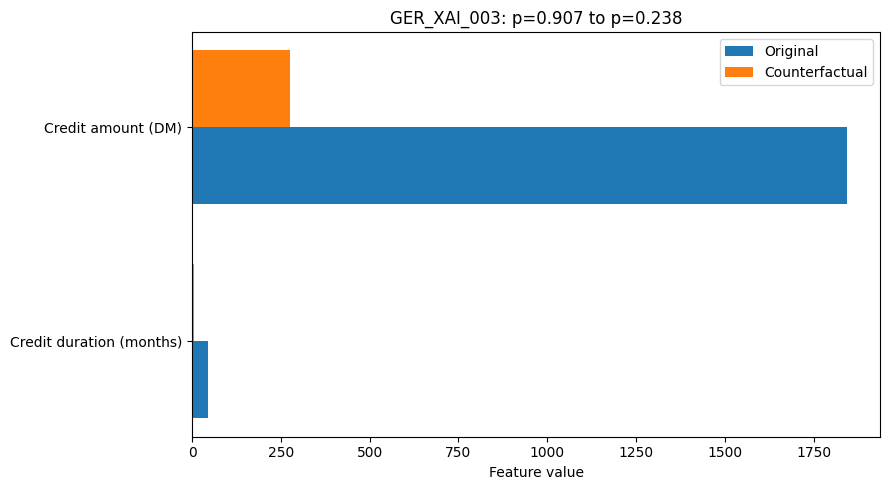

Representative case: GER_XAI_003


In [12]:
plain_rows = []
for cf in valid_counterfactuals.itertuples(index=False):
    changes = dice_feature_changes.loc[
        dice_feature_changes["counterfactual_id"].eq(cf.counterfactual_id)
        & dice_feature_changes["changed"]
    ]
    phrases = [
        f"{row.display_feature} changes from {row.original_value:g} to {row.counterfactual_value:g}"
        for row in changes.itertuples(index=False)
    ]
    direction = "lower risk" if int(cf.counterfactual_class) == 0 else "higher risk"
    plain_rows.append({
        "case_id": cf.case_id, "counterfactual_id": cf.counterfactual_id,
        "explanation": (
            f"The model prediction changes to {direction} if " + ", and ".join(phrases)
            + ". Other application details remain fixed. This is not financial advice or a guarantee of approval."
        ),
    })
dice_plain = pd.DataFrame(plain_rows)
PLAIN_PATH = ARTIFACTS_DIR / "dice_plain_english.csv"
atomic_csv(dice_plain, PLAIN_PATH)

REPRESENTATIVE_PLOT_PATH = PLOTS_DIR / "german_credit_dice_representative_counterfactual.png"
representative_case_id = None
if len(valid_counterfactuals):
    if valid_counterfactuals["case_id"].eq("GER_XAI_001").any():
        representative_case_id = "GER_XAI_001"
    else:
        eligible_ids = xai_cases.loc[xai_cases["case_type"].eq("high-confidence positive"), "case_id"]
        available = [case_id for case_id in eligible_ids if valid_counterfactuals["case_id"].eq(case_id).any()]
        representative_case_id = available[0] if available else valid_counterfactuals.iloc[0]["case_id"]
    representative_cf = valid_counterfactuals.loc[valid_counterfactuals["case_id"].eq(representative_case_id)].iloc[0]
    plot_changes = dice_feature_changes.loc[
        dice_feature_changes["counterfactual_id"].eq(representative_cf["counterfactual_id"])
        & dice_feature_changes["changed"]
    ]
    positions = np.arange(len(plot_changes))
    width = 0.36
    plt.figure(figsize=(9, 5))
    plt.barh(positions - width / 2, plot_changes["original_value"], height=width, label="Original")
    plt.barh(positions + width / 2, plot_changes["counterfactual_value"], height=width, label="Counterfactual")
    plt.yticks(positions, plot_changes["display_feature"])
    plt.xlabel("Feature value")
    plt.title(
        f"{representative_case_id}: p={representative_cf['original_probability']:.3f} to "
        f"p={representative_cf['counterfactual_probability']:.3f}"
    )
    plt.legend(); plt.tight_layout()
    plt.savefig(REPRESENTATIVE_PLOT_PATH, dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("No valid counterfactual exists in the saved results; no representative plot created.")
print(f"Representative case: {representative_case_id}")


## 12. Case summary and metadata


In [13]:
summary_rows = []
for case in case_generation_table.itertuples(index=False):
    valid = valid_counterfactuals.loc[valid_counterfactuals["case_id"].eq(case.case_id)]
    status = final_status.loc[final_status["case_id"].eq(case.case_id)].iloc[0]
    first = first_pass.loc[first_pass["case_id"].eq(case.case_id)].iloc[0]
    if len(valid):
        cf = valid.iloc[0]
        sparse = dice_sparsity.loc[dice_sparsity["case_id"].eq(case.case_id)].iloc[0]
        proximity = dice_proximity.loc[dice_proximity["case_id"].eq(case.case_id)].iloc[0]
        best_probability = cf["counterfactual_probability"]
        minimum_changed = sparse["number_of_changed_actionable_features"]
        best_proximity = proximity["normalized_proximity_score"]
    else:
        best_probability = minimum_changed = best_proximity = np.nan
    message = first["error_message"] if first["error_message"] else (
        "Independently valid counterfactual returned." if len(valid)
        else "Counterfactual search completed without a returned valid counterfactual."
    )
    summary_rows.append({
        "case_id": case.case_id, "case_type": case.case_type,
        "original_probability": case.original_probability,
        "original_class": case.original_class, "desired_class": case.desired_class,
        "counterfactuals_found": int(first["counterfactuals_found"]),
        "valid_counterfactuals": len(valid),
        "best_counterfactual_probability": best_probability,
        "minimum_changed_actionable_features": minimum_changed,
        "best_proximity_score": best_proximity,
        "generation_status": status["final_status"],
        "generation_message": message,
    })
dice_case_summary = pd.DataFrame(summary_rows)
CASE_SUMMARY_PATH = ARTIFACTS_DIR / "dice_case_summary.csv"
atomic_csv(dice_case_summary, CASE_SUMMARY_PATH)

first_counts = first_pass["generation_status"].value_counts().to_dict()
retry_counts = retry_results["retry_status"].value_counts().to_dict() if len(retry_results) else {}
DICE_METADATA_PATH = ARTIFACTS_DIR / "dice_metadata.json"
dice_metadata = {
    "dataset": "UCI Statlog German Credit Data (ID 144)",
    "model_path": str(paths["model"].relative_to(BACKEND_DIR)),
    "preprocessor_path": str(paths["preprocessor"].relative_to(BACKEND_DIR)),
    "training_reference_rows": len(dice_reference),
    "fixed_xai_case_count": len(xai_cases),
    "method": DICE_METHOD, "total_CFs": TOTAL_CFS, "random_state": RANDOM_STATE,
    "features_to_vary": FEATURES_TO_VARY,
    "permitted_ranges": permitted_range,
    "first_pass_timeout_seconds": FIRST_PASS_TIMEOUT_SECONDS,
    "retry_timeout_seconds": RETRY_TIMEOUT_SECONDS,
    "first_pass_outcome_counts": first_counts,
    "retry_outcome_counts": retry_counts,
    "final_valid_counterfactual_count": len(valid_counterfactuals),
    "model_retrained": False, "preprocessor_refitted": False,
}
DICE_METADATA_PATH.write_text(json.dumps(dice_metadata, indent=2), encoding="utf-8")
display(dice_case_summary)


,case_id,case_type,original_probability,original_class,desired_class,counterfactuals_found,valid_counterfactuals,best_counterfactual_probability,minimum_changed_actionable_features,best_proximity_score,generation_status,generation_message
0,GER_XAI_001,high-confidence positive,0.946682,1,0,0,0,NaN,NaN,NaN,no_counterfactual_returned_first_pass,No counterfactuals found for any of the query ...
1,GER_XAI_002,high-confidence positive,0.925695,1,0,0,0,NaN,NaN,NaN,no_counterfactual_returned_first_pass,No counterfactuals found for any of the query ...
2,GER_XAI_003,high-confidence positive,0.906782,1,0,1,1,0.237595,2.0,0.398281,success_first_pass,Independently valid counterfactual returned.
3,GER_XAI_004,high-confidence positive,0.906360,1,0,1,1,0.485312,2.0,0.107558,success_first_pass,Independently valid counterfactual returned.
4,GER_XAI_005,high-confidence positive,0.905507,1,0,1,1,0.280780,2.0,0.429916,success_first_pass,Independently valid counterfactual returned.
5,GER_XAI_006,borderline positive,0.501852,1,0,1,1,0.413880,2.0,0.162086,success_first_pass,Independently valid counterfactual returned.
6,GER_XAI_007,borderline positive,0.503441,1,0,1,1,0.440990,1.0,0.026039,success_first_pass,Independently valid counterfactual returned.
7,GER_XAI_008,borderline positive,0.513555,1,0,1,1,0.280480,2.0,0.081251,success_first_pass,Independently valid counterfactual returned.
8,GER_XAI_009,borderline positive,0.515243,1,0,1,1,0.362640,2.0,0.053635,success_first_pass,Independently valid counterfactual returned.
9,GER_XAI_010,borderline positive,0.517682,1,0,1,1,0.446994,2.0,0.433741,success_first_pass,Independently valid counterfactual returned.


## 13. Quality checks


In [14]:
assert hasattr(model, "classes_")
assert len(X_train_raw) == 800 and len(X_test_raw) == 200
assert wrapper_max_difference <= 1e-12
assert len(xai_cases) == 20
assert FEATURES_TO_VARY == ["Attribute2", "Attribute5", "Attribute8"]
assert len(first_pass) == 20
assert set(retry_results["case_id"]) == set(actual_timeout_ids)
assert len(final_status) == 20
if len(valid_counterfactuals):
    assert valid_counterfactuals["valid_counterfactual"].astype(str).str.lower().eq("true").all()
    assert valid_counterfactuals[selected_features].notna().all().all()
    assert dice_feature_changes.groupby("counterfactual_id").size().eq(3).all()
    assert set(dice_feature_changes["feature"]) == set(FEATURES_TO_VARY)

print("Frozen model loaded: True")
print("Exact train rows reconstructed: 800")
print("Exact test rows reconstructed: 200")
print("Frozen predictions reproduced: True")
print("Fixed XAI cases: 20")
print(f"First-pass outcomes: {first_counts}")
print(f"Retry outcomes: {retry_counts}")
print(f"Final valid counterfactuals: {len(valid_counterfactuals)}")
print("Every valid CF complete raw row persisted: True")
print("Feature-change audit persisted: True")
print("Model retrained: False")
print("Preprocessor refitted: False")
print("New split created: False")
print("SHAP rerun: False")
print("LIME rerun: False")
print("Dataset 1 modified: False")


Frozen model loaded: True
Exact train rows reconstructed: 800
Exact test rows reconstructed: 200
Frozen predictions reproduced: True
Fixed XAI cases: 20
First-pass outcomes: {'success': 12, 'no_counterfactual_returned': 8}
Retry outcomes: {}
Final valid counterfactuals: 12
Every valid CF complete raw row persisted: True
Feature-change audit persisted: True
Model retrained: False
Preprocessor refitted: False
New split created: False
SHAP rerun: False
LIME rerun: False
Dataset 1 modified: False
